In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Read the analysis results
pt_results_dirpath = "data/pt-sim-results/"
pt_scenarios_results = pd.read_csv(os.path.join(pt_results_dirpath, "all_pt_scenario_level_analysis_results.csv"))
print(f"PT Columns: {pt_scenarios_results.columns.tolist()}")

amod_results_dirpath = "data/amod-sim-results/"
amod_scenarios_results = pd.read_csv(os.path.join(amod_results_dirpath, "all_amod_scenario_level_analysis_results.csv"))
print(f"AMoD Columns: {amod_scenarios_results.columns.tolist()}")

PT Columns: ['average_journey_time', 'average_pt_service_rate', 'average_intracity_journey_time', 'average_intercity_journey_time', 'pt_network_name', 'train_headway', 'bus_headway', 'demand_size', 'intra_ratio', 'random_seed']
AMoD Columns: ['fleet_utilization_rate', 'distance_avg_occupancy', 'total_km_driven', 'average_km_driven', 'total_amod_cost', 'average_amod_cost', 'total_amod_fix_cost', 'total_amod_variable_cost', 'total_co2_emissions_g', 'total_external_emission_costs', 'average_amod_service_rate', 'average_journey_time', 'average_pt_waiting_time', 'average_intercity_journey_time', 'average_intracity_journey_time', 'random_seed', 'fleet_size', 'demand_size', 'intra_ratio', 'broker_type', 'op_max_detour_time_factor', 'op_max_wait_time', 'train_headway', 'scenario_name']


# Filter

In [3]:
# Remove default results in AMoD simulations
amod_scenarios_results = amod_scenarios_results[amod_scenarios_results['broker_type'] != 'default']

# Varibales

In [4]:
# Train Headway (min)
train_headway_list = [10, 20, 30]

# MoD Fleet Size
mod_fleet_size_list = [30, 50, 70, 90, 110, 130, 150]

# MaaS Platform Communication Strategy
maas_communication_strategy_list = ['default', 'TPCS']

# BUS Network
bus_network_list = ['basic', 'diagonal', 'ring', 'mature']

# Random Seed
random_seed_list = [3, 6, 9]

# MoD Waiting Time Threshold (s)
mod_waiting_time_threshold_list = [300, 600, 900]
# MoD Detour Time Threshold (%)
mod_detour_time_threshold_list = [30, 60, 90]

# Demand Size
demand_size_list = [i for i in range(100, 1001, 100)]
# Demand Split Ratio (Intra Modal, %)
demand_split_ratio_list = [0, 20, 40, 60, 80]

name_dict = {
    'random_seed': "Random Seed", 
    'fleet_size': "Fleet Size",
    'demand_size': "Demand Size",
    'intra_ratio': "Intra Demand Ratio",
    'op_max_detour_time_factor': "Max Detour Time Factor",
    'op_max_wait_time': "Max Wait Time",
    'pt_network_name': 'PT Network',
    'train_headway': "Train Headway",
    'average_journey_time': "Average Journey Time",
    'average_intercity_journey_time': "Average Intercity Journey Time",
    'average_intracity_journey_time': "Average Intracity Journey Time",
    'average_amod_service_rate': "Average AMoD Service Rate",
    'average_pt_service_rate': 'Average PT Service Rate'
}

variable_name_list = ['demand_size', 'intra_ratio', 'train_headway', 'random_seed']

In [5]:
def draw_interaction_plots_comparison(
    kpi_column,
    y_axis_limit,
    data1,
    data2=None,
    data1_label='bus',
    data2_label='mod',
    errorbar=('ci', 95),
    strategy_column_1='pt_network_name',
    strategy_column_2='broker_type',
    variable_name_list=variable_name_list, 
    name_dict=name_dict
):

    source_type_col = 'source_type'

    if data2 is not None:
        data1_copy = data1.copy()
        data1_copy[source_type_col] = data1_label
        # Rename strategy column
        data1_copy.rename(columns={strategy_column_1: 'strategy'}, inplace=True)
        
        data2_copy = data2.copy()
        data2_copy[source_type_col] = data2_label
        # Rename strategy column
        data2_copy.rename(columns={strategy_column_2: 'strategy'}, inplace=True)
        
        combined_data = pd.concat([data1_copy, data2_copy], ignore_index=True)
        
        hue_col = 'strategy'
        style_col = 'strategy'
        legend_title = None
    else:
        combined_data = data1.copy()
        # Rename strategy column
        combined_data.rename(columns={strategy_column_1: 'strategy'}, inplace=True)
        hue_col = 'strategy'
        style_col = 'strategy'
        legend_title = 'Strategy'

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    flat_axes = axes.flatten()

    handles, labels = [], []

    for i, variable_name in enumerate(variable_name_list):  
        ax = flat_axes[i]
        
        sns.set_style("whitegrid")

        sns.lineplot(
            data=combined_data,
            x=variable_name,
            y=kpi_column,
            hue=hue_col,    
            style=style_col, 
            markers=True,
            dashes=False, 
            errorbar=errorbar,
            ax=ax,
            legend='auto'
        )

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()
        
        ax.set_xlabel(f'{name_dict.get(variable_name, variable_name)}', fontsize=16)
        ax.set_ylabel(f'{name_dict.get(kpi_column, kpi_column)}', fontsize=16)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

        x_ticks_to_show = sorted(combined_data[variable_name].unique())
        ax.set_xticks(x_ticks_to_show)

        ax.tick_params(labelsize=16)
        
        if y_axis_limit: 
            ax.set_ylim(y_axis_limit)

    legend_ax_index = len(flat_axes) - 1
    legend_ax = flat_axes[legend_ax_index]

    if handles and labels:
        if len(variable_name_list) > legend_ax_index:
            legend_loc = 'lower right'
            legend_bbox = legend_ax.get_position()
        else:
            legend_ax.axis('off')
            legend_loc = 'center'
            legend_bbox = legend_ax.get_position()

        fig.legend(
            handles, 
            labels, 
            title=legend_title,
            loc=legend_loc, 
            bbox_to_anchor=legend_bbox,
            ncol=1,
            fontsize=16,
            title_fontsize=16
        )
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

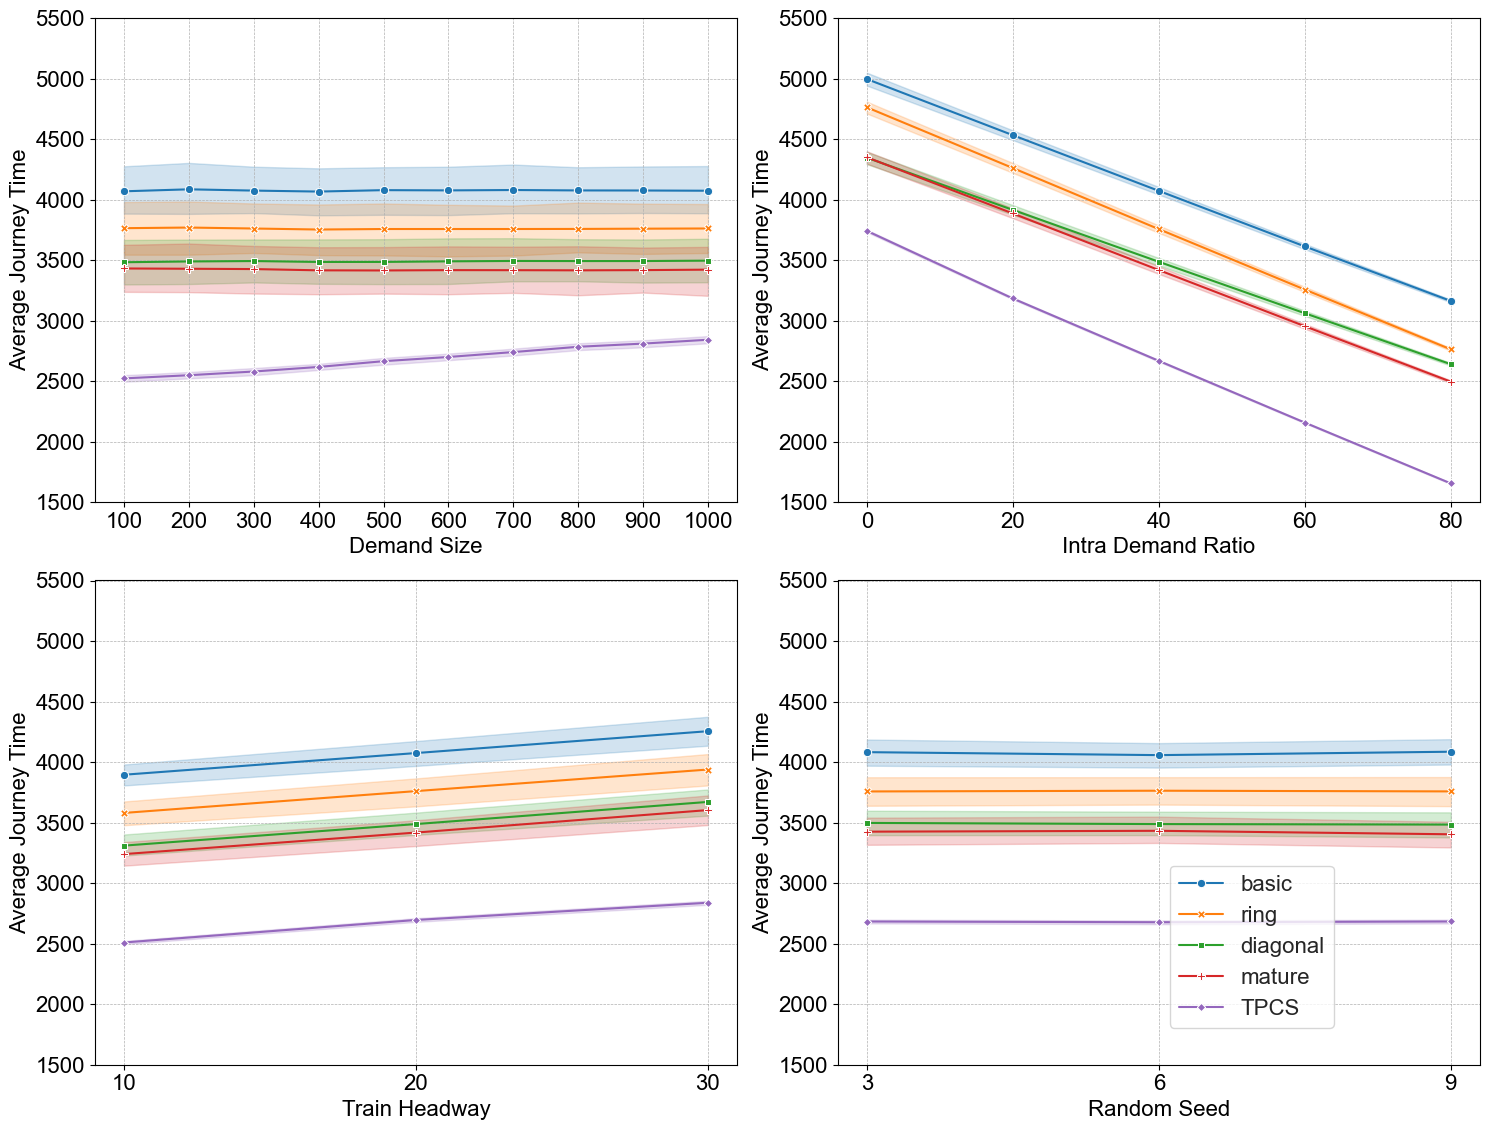

In [6]:
draw_interaction_plots_comparison(
    kpi_column='average_journey_time', y_axis_limit=(1500, 5500),
    data1=pt_scenarios_results,
    data2=amod_scenarios_results,
    data1_label='bus',
    data2_label='mod',
    errorbar=('ci', 95),
    strategy_column_1='pt_network_name',
    strategy_column_2='broker_type',
    variable_name_list=variable_name_list, 
    name_dict=name_dict
)

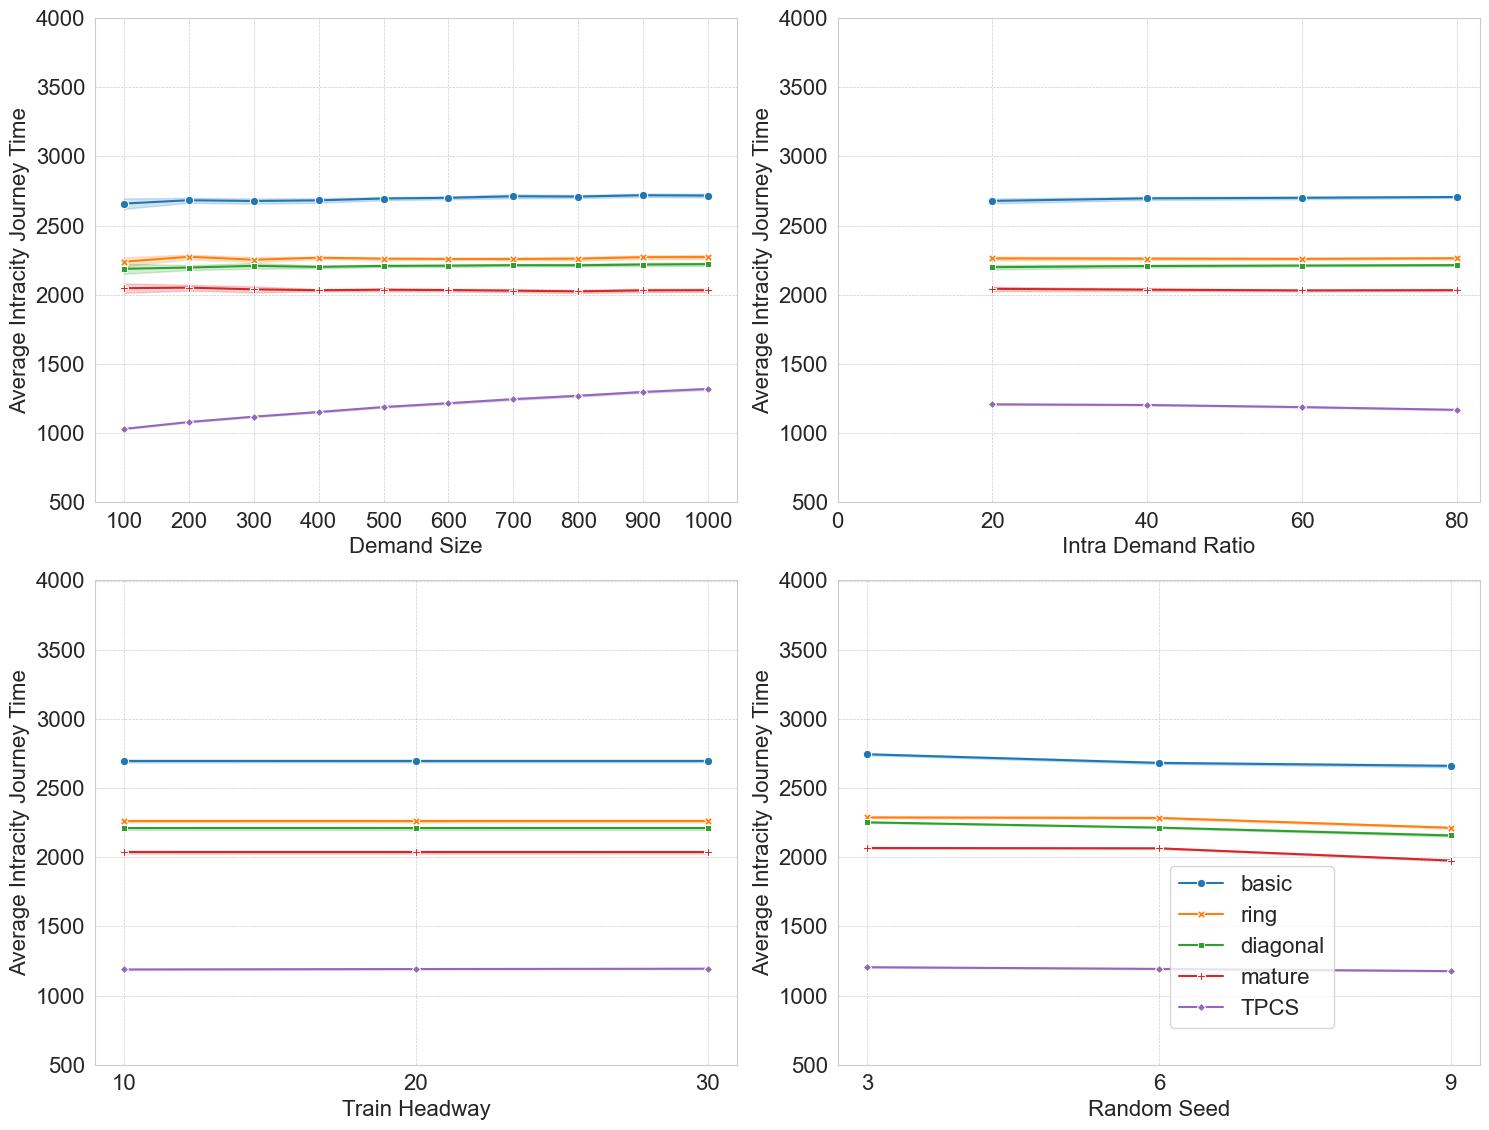

In [7]:
draw_interaction_plots_comparison(
    kpi_column='average_intracity_journey_time', y_axis_limit=(500, 4000),
    data1=pt_scenarios_results,
    data2=amod_scenarios_results,
    data1_label='bus',
    data2_label='mod',
    errorbar=('ci', 95),
    strategy_column_1='pt_network_name',
    strategy_column_2='broker_type',
    variable_name_list=variable_name_list, 
    name_dict=name_dict
)

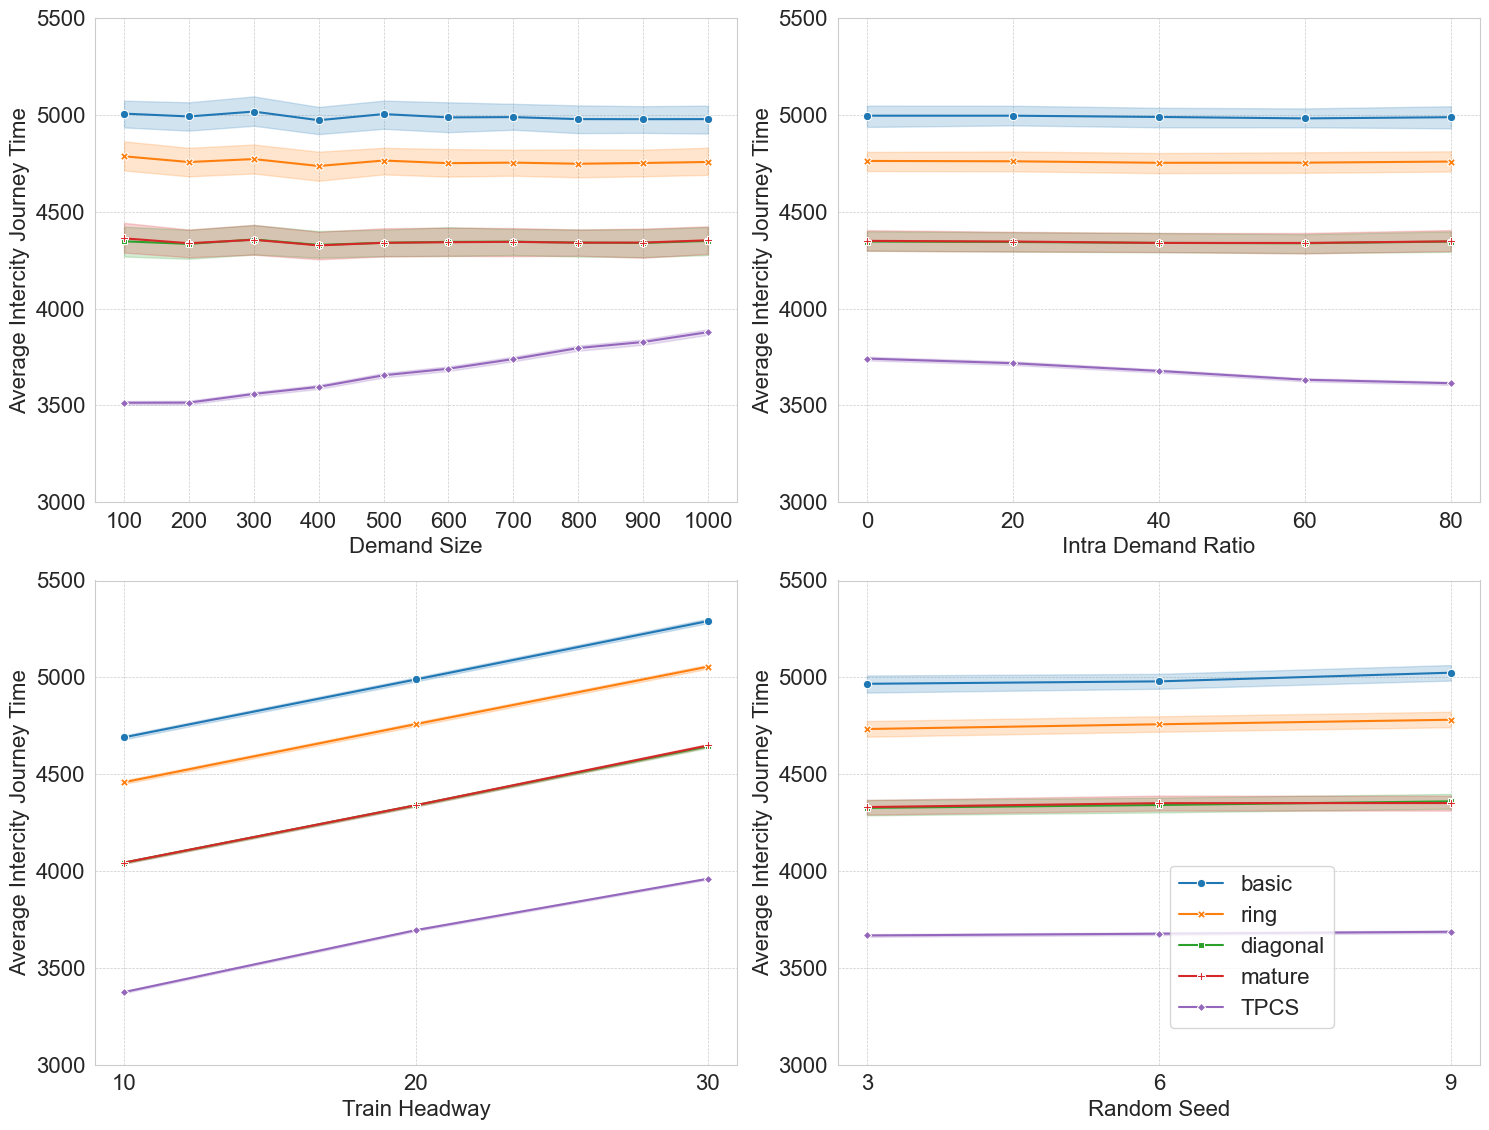

In [8]:
draw_interaction_plots_comparison(
    kpi_column='average_intercity_journey_time', y_axis_limit=(3000, 5500),
    data1=pt_scenarios_results,
    data2=amod_scenarios_results,
    data1_label='bus',
    data2_label='mod',
    errorbar=('ci', 95),
    strategy_column_1='pt_network_name',
    strategy_column_2='broker_type',
    variable_name_list=variable_name_list, 
    name_dict=name_dict
)